<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15476\2687668295.py:6: SyntaxWarning: "

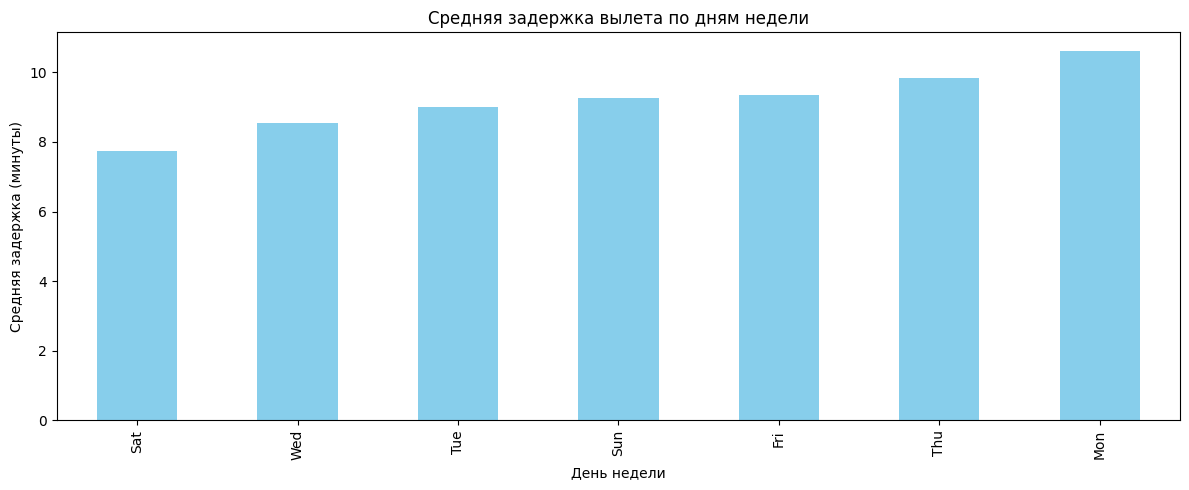

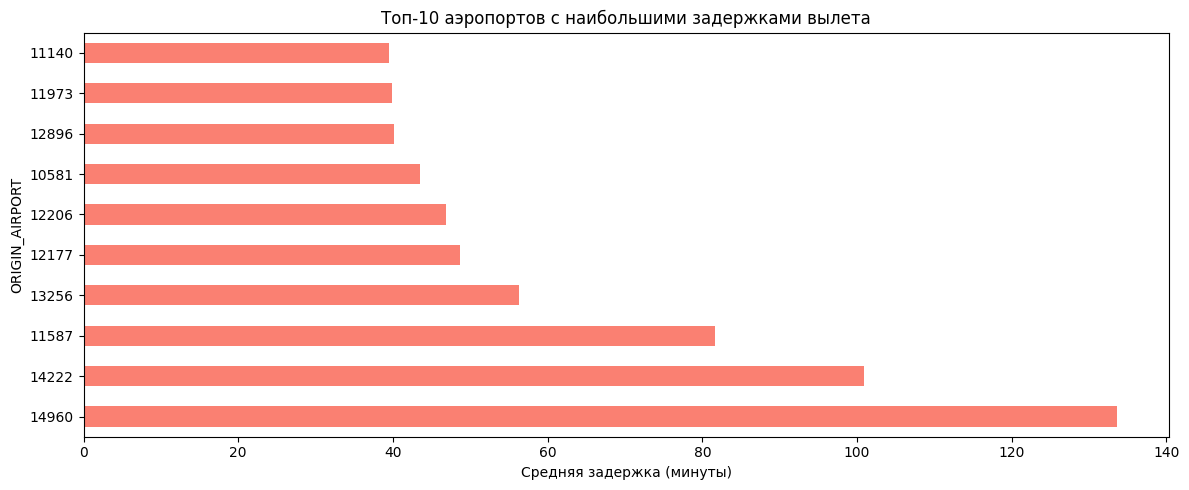

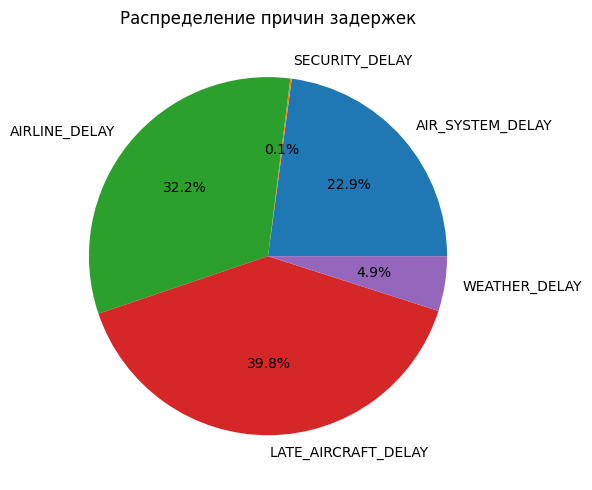

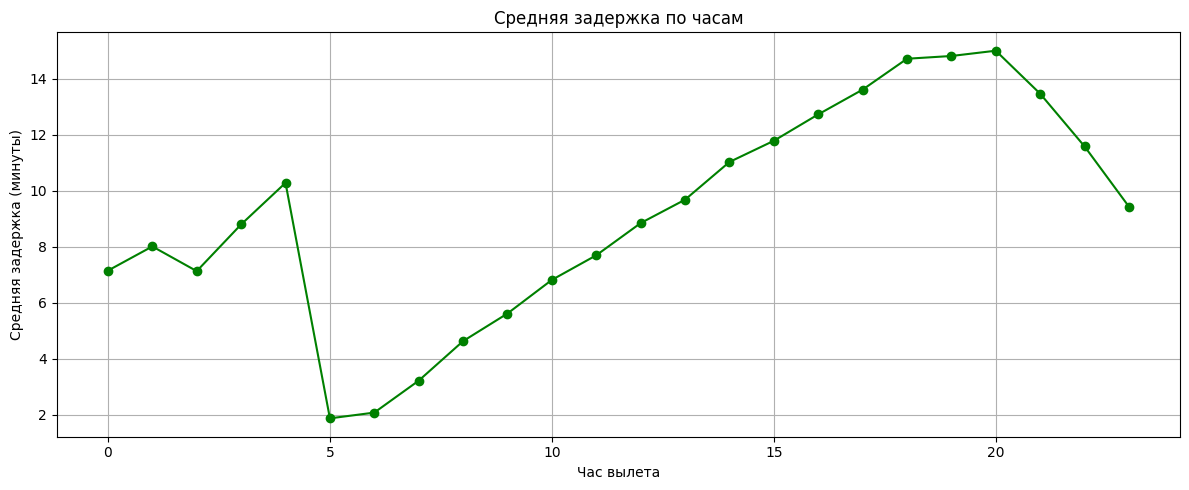

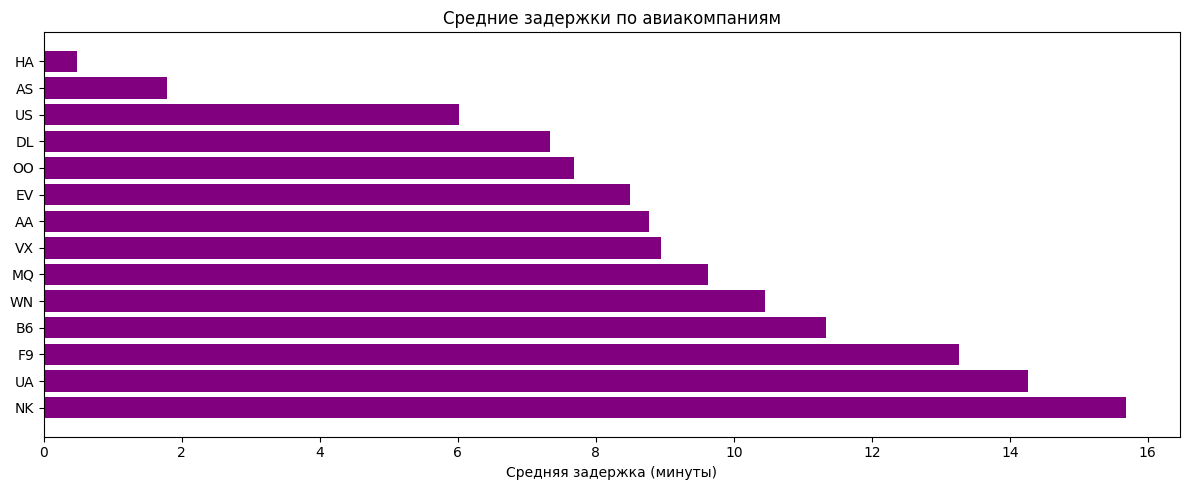

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

flights = pd.read_csv("C:\\Users\\ASUS\\Documents\\Prac\homework_1\\flights.csv")
airports = pd.read_csv("C:\\Users\\ASUS\\Documents\Prac\homework_1\\airports.csv")
airlines = pd.read_csv("C:\\Users\ASUS\\Documents\\Prac\\homework_1\\airlines.csv")


flights['DEPARTURE_DELAY'] = flights['DEPARTURE_DELAY'].fillna(0)
flights['ARRIVAL_DELAY'] = flights['ARRIVAL_DELAY'].fillna(0)
flights['DAY_OF_WEEK'] = flights['DAY_OF_WEEK'].map({1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'})

# 1. Задержки по дням недели
plt.figure(figsize=(12,5))
daily_delays = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean().sort_values()
daily_counts = flights.groupby('DAY_OF_WEEK').size()
daily_delays.plot(kind='bar', color='skyblue')
plt.title('Средняя задержка вылета по дням недели')
plt.xlabel('День недели')
plt.ylabel('Средняя задержка (минуты)')
plt.tight_layout()
plt.show()

# 2. Топ-10 проблемных аэропортов
plt.figure(figsize=(12,5))
airport_delays = flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(10)
airport_delays.plot(kind='barh', color='salmon')
plt.title('Топ-10 аэропортов с наибольшими задержками вылета')
plt.xlabel('Средняя задержка (минуты)')
plt.tight_layout()
plt.show()


# 3. Причины задержек
delay_causes = flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                        'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].sum()
plt.figure(figsize=(10,5))
delay_causes.plot(kind='pie', autopct='%1.1f%%')
plt.title('Распределение причин задержек')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 4. Зависимость задержки от времени суток
flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100
hourly_delays = flights.groupby('HOUR')['DEPARTURE_DELAY'].mean()
plt.figure(figsize=(12,5))
hourly_delays.plot(kind='line', marker='o', color='green')
plt.title('Средняя задержка по часам')
plt.xlabel('Час вылета')
plt.ylabel('Средняя задержка (минуты)')
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Задержки по авиакомпаниям
airline_delays = flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(15)
airline_delays = airline_delays.reset_index()
#airline_delays = airline_delays.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')

plt.figure(figsize=(12,5))
plt.barh(airline_delays['AIRLINE'], airline_delays['DEPARTURE_DELAY'], color='purple')
plt.title('Средние задержки по авиакомпаниям')
plt.xlabel('Средняя задержка (минуты)')
plt.tight_layout()
plt.show()